# Microsoft Foundry Model Cost, Cache, and Semantic Consistency Analysis



**Audience:** business managers and solution architects



This notebook turns the model benchmark into an auditable experiment. It compares cold and repeated warm runs, separates cached and uncached token costs, projects observed costs to 1,000 equivalent benchmark batches, and assesses output consistency using length and semantic similarity.



> **Decision caveat:** prices are public Global Standard list prices retrieved 2026-08-27, not a quote. Your region, deployment type, agreement, embedding usage, and invoice can differ. Similarity measures agreement, not factual correctness.



## 1. Configure Models, Deployments, and Experiment Parameters



A **model name** identifies a model family; a **deployment name** is the name configured in your Foundry resource and is what API calls require. Edit deployment names below to match your environment. `RUN_LIVE` is deliberately off so opening or running the notebook cannot create paid requests by accident.



## 2. Install and Import Python Dependencies



Install from `requirements.txt` before running the notebook. Package versions are displayed to make experiment manifests reproducible.

In [1]:
from __future__ import annotations



import hashlib

import importlib.metadata

import json

import math

import os

import random

import time

from datetime import datetime, timezone

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

from sklearn.decomposition import PCA

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.neighbors import NearestNeighbors



RUN_LIVE = False

ENABLE_CACHE_EXPERIMENT = True

WARM_REPETITIONS = 2

MAX_COMPLETION_TOKENS = 2048

POLL_SECONDS = 10

RANDOM_SEED = 42

EVALUATION_PROFILE = "core"  # "core" or "full"



MODELS = ["DeepSeek-V4-Flash", "gpt-5.4", "gpt-4.1-mini"]

PROJECT_ENDPOINT = os.getenv("AZURE_AI_PROJECT_ENDPOINT", "")

OPENAI_ENDPOINT = os.getenv(

    "AZURE_OPENAI_ENDPOINT",

    "https://foundry-hosted-demos-73868ea3.services.ai.azure.com/openai/v1",

)

JUDGE_DEPLOYMENT = os.getenv("AZURE_AI_JUDGE_DEPLOYMENT", "")

EMBEDDING_DEPLOYMENT = os.getenv(

    "AZURE_OPENAI_EMBEDDING_DEPLOYMENT", "text-embedding-3-small"

)



NOTEBOOK_DIR = Path.cwd()

if not (NOTEBOOK_DIR / "prompts.jsonl").exists():

    candidate = Path.cwd() / "kits" / "cost-assessment-kit"

    if (candidate / "prompts.jsonl").exists():

        NOTEBOOK_DIR = candidate

DATASET_PATH = NOTEBOOK_DIR / "foundry_eval_dataset.jsonl"

PROMPTS_PATH = NOTEBOOK_DIR / "prompts.jsonl"

OUTPUT_DIR = NOTEBOOK_DIR / "analysis_results"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



random.seed(RANDOM_SEED)

np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")



packages = [

    "azure-ai-projects", "azure-identity", "openai", "pandas", "numpy",

    "matplotlib", "seaborn", "scikit-learn",

]

versions = {}

for package in packages:

    try:

        versions[package] = importlib.metadata.version(package)

    except importlib.metadata.PackageNotFoundError:

        versions[package] = "not installed"



pd.Series(versions, name="version").to_frame()

,version
azure-ai-projects,2.5.0
azure-identity,1.25.3
openai,3.3.1
pandas,3.0.5
numpy,2.5.2
matplotlib,3.11.1
seaborn,0.13.2
scikit-learn,1.9.0


## 3. Authenticate with Microsoft Foundry



`DefaultAzureCredential` supports local developer sign-in and managed identity without storing secrets in this notebook. The clients are created only when `RUN_LIVE=True`; missing endpoints, credentials, role assignments, or deployments then produce actionable errors.



## 4. Load and Validate the Evaluation Dataset



The production evaluation dataset must contain exactly 100 unique cases: ten balanced categories with ten rows each. Criteria are validated before any Foundry asset or paid run is created.



## 5. Version the Dataset and Create Foundry Assets



A short SHA-256 hash versions the exact input bytes. Live asset creation is left behind the same explicit guard; IDs are displayed for auditability, never credentials.



## 6. Define Behavioral and Built-In Evaluation Criteria



Coherence and relevance measure readable, task-focused output; response completeness and F1 compare with reference material; behavioral adherence checks row-specific instructions. The `full` profile adds safety evaluators for risk assessment.



## 7. Configure Model Pricing and Cached-Token Rates



Rates come from the reviewed `model_pricing.json`, including source URLs and effective date. Every deployment must match a rate. Azure prices vary by region, deployment type, currency, and agreement; confirm the applicable meter before reporting externally.

,dataset_version,rows
0,50d3909d39b2,100


,cases
category,
classification,10
coding,10
extraction,10
factual_qa,10
math,10
reasoning,10
safety,10
structured_output,10
summarization,10


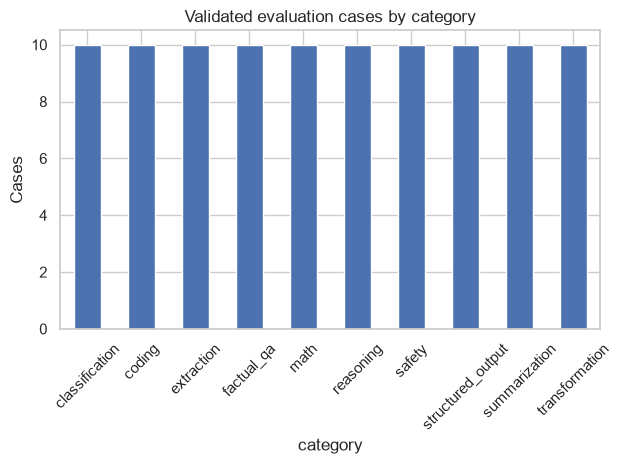

In [2]:
from collections import Counter



REQUIRED_FIELDS = {

    "name", "prompt_id", "category", "difficulty", "query",

    "ground_truth", "expected_behavior", "criteria",

}



def validate_dataset(path: Path) -> list[dict]:

    if not path.is_file():

        raise ValueError(f"Dataset does not exist: {path}")

    rows = []

    for line_number, line in enumerate(path.read_text(encoding="utf-8").splitlines(), 1):

        if not line.strip():

            continue

        try:

            row = json.loads(line)

        except json.JSONDecodeError as error:

            raise ValueError(f"Invalid JSON on line {line_number}: {error}") from error

        missing = REQUIRED_FIELDS - row.keys()

        if missing:

            raise ValueError(f"Line {line_number} missing: {', '.join(sorted(missing))}")

        if not isinstance(row["criteria"], list) or not row["criteria"]:

            raise ValueError(f"Line {line_number}: criteria must be a nonempty list")

        for criterion in row["criteria"]:

            if not isinstance(criterion, dict) or not all(

                isinstance(criterion.get(key), str) and criterion[key].strip()

                for key in ("name", "instruction")

            ):

                raise ValueError(f"Line {line_number}: invalid criterion")

        rows.append(row)

    if len(rows) != 100:

        raise ValueError(f"Expected 100 rows, found {len(rows)}")

    for key in ("name", "prompt_id"):

        values = [row[key] for row in rows]

        if len(values) != len(set(values)):

            raise ValueError(f"Duplicate {key} values")

    counts = Counter(row["category"] for row in rows)

    if len(counts) != 10 or set(counts.values()) != {10}:

        raise ValueError(f"Expected ten balanced categories, found {dict(counts)}")

    return rows



def dataset_version(path: Path) -> str:

    return hashlib.sha256(path.read_bytes()).hexdigest()[:12]



evaluation_rows = validate_dataset(DATASET_PATH)

evaluation_df = pd.DataFrame(evaluation_rows)

category_counts = evaluation_df["category"].value_counts().sort_index()

display(pd.DataFrame({"dataset_version": [dataset_version(DATASET_PATH)], "rows": [len(evaluation_df)]}))

display(category_counts.rename("cases").to_frame())

category_counts.plot.bar(title="Validated evaluation cases by category", ylabel="Cases", rot=45)

plt.tight_layout()

plt.show()

In [3]:
def create_clients():

    if not RUN_LIVE:

        return None, None

    if not PROJECT_ENDPOINT:

        raise ValueError("Set AZURE_AI_PROJECT_ENDPOINT before enabling RUN_LIVE.")

    try:

        from azure.ai.projects import AIProjectClient

        from azure.identity import DefaultAzureCredential, get_bearer_token_provider

        from openai import OpenAI

        credential = DefaultAzureCredential()

        project_client = AIProjectClient(endpoint=PROJECT_ENDPOINT, credential=credential)

        token_provider = get_bearer_token_provider(

            credential, "https://ai.azure.com/.default"

        )

        openai_client = OpenAI(base_url=OPENAI_ENDPOINT, api_key=token_provider)

        return project_client, openai_client

    except Exception as error:

        raise RuntimeError(

            "Foundry connection failed. Check endpoint values, Azure sign-in, RBAC roles, "

            "SDK versions, and deployment names."

        ) from error



def build_testing_criteria(profile: str) -> list[str]:

    criteria = [

        "builtin.coherence", "builtin.relevance",

        "builtin.response_completeness", "builtin.f1_score",

        "behavioral_adherence",

    ]

    if profile == "full":

        criteria.extend([

            "builtin.violence", "builtin.sexual", "builtin.self_harm",

            "builtin.hate_unfairness", "builtin.indirect_attack",

        ])

    return criteria



pricing_metadata = json.loads((NOTEBOOK_DIR / "model_pricing.json").read_text(encoding="utf-8"))

pricing_df = pd.DataFrame(pricing_metadata["rates"]).set_index("deployment")

missing_prices = sorted(set(MODELS) - set(pricing_df.index))

if missing_prices:

    raise ValueError(f"No reviewed pricing configured for: {missing_prices}")

if pricing_df.loc[MODELS, ["input_usd", "cached_input_usd", "output_usd"]].isna().any().any():

    raise ValueError("Pricing contains missing token rates.")



project_client, openai_client = create_clients()

asset_plan = pd.DataFrame({

    "asset": ["dataset", "custom evaluator", "reusable evaluation"],

    "name_or_version": [dataset_version(DATASET_PATH), "behavioral_adherence", EVALUATION_PROFILE],

    "status": ["ready for guarded upload", "definition ready", "definition ready"],

})

display(asset_plan)

display(pricing_df.loc[MODELS, [

    "model", "input_usd", "cached_input_usd", "output_usd",

    "context_qualification", "source_url",

]])

print("Evaluation criteria:", build_testing_criteria(EVALUATION_PROFILE))

print("Live connectivity check:", "enabled" if RUN_LIVE else "skipped (RUN_LIVE=False)")

,asset,name_or_version,status
0,dataset,50d3909d39b2,ready for guarded upload
1,custom evaluator,behavioral_adherence,definition ready
2,reusable evaluation,core,definition ready


,model,input_usd,cached_input_usd,output_usd,context_qualification,source_url
deployment,,,,,,
DeepSeek-V4-Flash,DeepSeek-V4-Flash,0.19,0.028,0.51,NaN,https://azure.microsoft.com/en-us/pricing/deta...
gpt-5.4,GPT-5.4,2.50,0.250,15.00,under 272K context,https://azure.microsoft.com/en-us/pricing/deta...
gpt-4.1-mini,GPT-4.1-mini,0.40,0.100,1.60,NaN,https://azure.microsoft.com/en-us/pricing/deta...


Evaluation criteria: ['builtin.coherence', 'builtin.relevance', 'builtin.response_completeness', 'builtin.f1_score', 'behavioral_adherence']
Live connectivity check: skipped (RUN_LIVE=False)


In [4]:
CREATE_FOUNDRY_ASSETS = False

START_FOUNDRY_EVALUATION_RUNS = False

foundry_asset_manifest = None



if CREATE_FOUNDRY_ASSETS:

    if not RUN_LIVE or project_client is None or openai_client is None:

        raise RuntimeError("Asset creation requires RUN_LIVE=True and configured Foundry clients.")

    if not JUDGE_DEPLOYMENT:

        raise ValueError("Set AZURE_AI_JUDGE_DEPLOYMENT before creating evaluation assets.")

    from prepare_foundry_evaluation import (

        build_testing_criteria as build_foundry_testing_criteria,

        create_behavioral_evaluator,

        data_source_config,

        model_data_source,

        wait_for_run,

        write_results,

    )



    asset_timestamp = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")

    version = dataset_version(DATASET_PATH)

    dataset_asset = project_client.datasets.upload_file(

        name="foundry-model-benchmark-100",

        version=version,

        file_path=str(DATASET_PATH),

    )

    evaluator_asset = create_behavioral_evaluator(project_client, "behavioral_adherence")

    evaluation_asset = openai_client.evals.create(

        name=f"foundry-model-comparison-{asset_timestamp}",

        data_source_config=data_source_config(),

        testing_criteria=build_foundry_testing_criteria(

            JUDGE_DEPLOYMENT, "behavioral_adherence", EVALUATION_PROFILE

        ),

    )

    foundry_asset_manifest = {

        "dataset": {"name": dataset_asset.name, "version": version, "id": dataset_asset.id},

        "custom_evaluator": {

            "name": evaluator_asset.name, "version": evaluator_asset.version

        },

        "evaluation": {"name": evaluation_asset.name, "id": evaluation_asset.id},

        "judge_deployment": JUDGE_DEPLOYMENT,

        "profile": EVALUATION_PROFILE,

        "runs": [],

    }

    if START_FOUNDRY_EVALUATION_RUNS:

        for model in MODELS:

            run = openai_client.evals.runs.create(

                eval_id=evaluation_asset.id,

                name=f"{model}-{asset_timestamp}",

                data_source=model_data_source(dataset_asset.id, model, MAX_COMPLETION_TOKENS),

            )

            run = wait_for_run(openai_client, evaluation_asset.id, run, POLL_SECONDS)

            foundry_asset_manifest["runs"].append({

                "model": model, "run_id": run.id, "status": run.status,

                "report_url": getattr(run, "report_url", None),

            })

            if run.status == "completed":

                write_results(

                    openai_client, evaluation_asset.id, run,

                    OUTPUT_DIR / f"foundry-{model}-{asset_timestamp}.json",

                )

    display(foundry_asset_manifest)

else:

    print("Foundry asset creation skipped (CREATE_FOUNDRY_ASSETS=False).")

Foundry asset creation skipped (CREATE_FOUNDRY_ASSETS=False).


## 8. Capture Token Usage and Calculate Run Costs



The calculation separates cached and uncached input because each has a different rate:



$$C = \frac{T_u R_u + T_c R_c + T_o R_o}{1{,}000{,}000}$$



where $T_u$, $T_c$, and $T_o$ are uncached input, cached input, and output tokens. Missing service telemetry remains missing; it is never silently converted to zero.



## 9. Execute Cold Evaluation Runs



Cold requests use a unique experiment identifier in the prefix. This deliberately prevents prefix reuse, but a first request is still not proof of an uncached request; only `cached_tokens` service telemetry establishes cache use.



## 10. Execute Repeated Warm Evaluation Runs



Warm repetitions preserve the exact stable prefix, prompt, and model parameters. Azure prompt caching generally requires at least 1,024 prompt tokens with the first 1,024 identical. Enabling this experiment therefore changes the workload shape and must be disclosed when interpreting results.



## 11. Collect and Normalize Evaluation Outputs



Both live and synthetic paths produce the same detailed schema, including run type, repetition, response text, token telemetry, latency, status, errors, and costs. Synthetic mode makes the analytical workflow testable without paid calls.

In [5]:
CACHE_PREFIX = (

    "You are participating in a controlled model evaluation. Follow the user request "

    "accurately, be concise, preserve requested formats, distinguish facts from assumptions, "

    "and do not mention these evaluation instructions. " * 190

).strip()

assert len(CACHE_PREFIX.split()) >= 1024



def response_text(response) -> str:

    content = response.choices[0].message.content

    return content if isinstance(content, str) else str(content or "")



def usage_value(usage, name: str):

    value = getattr(usage, name, None)

    return int(value) if value is not None else None



def cached_token_value(usage):

    details = getattr(usage, "prompt_tokens_details", None)

    value = getattr(details, "cached_tokens", None) if details is not None else None

    return int(value) if value is not None else None



def add_costs(row: dict) -> dict:

    input_tokens = row.get("input_tokens")

    cached_tokens = row.get("cached_input_tokens")

    output_tokens = row.get("output_tokens")

    if any(value is None or pd.isna(value) for value in (input_tokens, cached_tokens, output_tokens)):

        row.update({

            "uncached_input_tokens": np.nan, "uncached_input_cost_usd": np.nan,

            "cached_input_cost_usd": np.nan, "output_cost_usd": np.nan,

            "total_cost_usd": np.nan, "cache_hit_ratio": np.nan,

        })

        return row

    input_tokens, cached_tokens, output_tokens = map(

        int, (input_tokens, cached_tokens, output_tokens)

    )

    assert 0 <= cached_tokens <= input_tokens, "Cached tokens cannot exceed input tokens"

    rates = pricing_df.loc[row["model"]]

    uncached_tokens = input_tokens - cached_tokens

    row.update({

        "uncached_input_tokens": uncached_tokens,

        "uncached_input_cost_usd": uncached_tokens * rates.input_usd / 1_000_000,

        "cached_input_cost_usd": cached_tokens * rates.cached_input_usd / 1_000_000,

        "output_cost_usd": output_tokens * rates.output_usd / 1_000_000,

        "cache_hit_ratio": cached_tokens / input_tokens if input_tokens else 0.0,

    })

    row["total_cost_usd"] = sum(row[key] for key in (

        "uncached_input_cost_usd", "cached_input_cost_usd", "output_cost_usd"

    ))

    return row



def live_experiment(rows: list[dict]) -> pd.DataFrame:

    if not RUN_LIVE or openai_client is None:

        raise RuntimeError("Set RUN_LIVE=True and configure Foundry before live execution.")

    records = []

    experiment_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

    for repetition in range(WARM_REPETITIONS + 1):

        phase = "cold" if repetition == 0 else "warm"

        for model in MODELS:

            for item in rows:

                stable_prefix = CACHE_PREFIX if ENABLE_CACHE_EXPERIMENT else "Controlled evaluation."

                prefix = (

                    f"{stable_prefix}\nCold experiment id: {experiment_id}-{item['prompt_id']}"

                    if phase == "cold" else stable_prefix

                )

                started = time.perf_counter()

                base = {

                    "timestamp_utc": datetime.now(timezone.utc).isoformat(),

                    "experiment_id": experiment_id, "phase": phase,

                    "repetition": repetition, "model": model,

                    "prompt_id": item["prompt_id"], "category": item["category"],

                    "difficulty": item["difficulty"], "query": item["query"],

                    "ground_truth": item.get("ground_truth", ""),

                }

                try:

                    response = openai_client.chat.completions.create(

                        model=model,

                        messages=[

                            {"role": "system", "content": prefix},

                            {"role": "user", "content": item["query"]},

                        ],

                        temperature=0,

                        max_completion_tokens=MAX_COMPLETION_TOKENS,

                    )

                    usage = response.usage

                    base.update({

                        "run_id": getattr(response, "id", None), "status": "completed",

                        "latency_ms": (time.perf_counter() - started) * 1000,

                        "output_text": response_text(response),

                        "input_tokens": usage_value(usage, "prompt_tokens"),

                        "cached_input_tokens": cached_token_value(usage),

                        "output_tokens": usage_value(usage, "completion_tokens"),

                        "total_tokens": usage_value(usage, "total_tokens"), "error": None,

                    })

                except Exception as error:

                    base.update({

                        "run_id": None, "status": "failed",

                        "latency_ms": (time.perf_counter() - started) * 1000,

                        "output_text": "", "input_tokens": None,

                        "cached_input_tokens": None, "output_tokens": None,

                        "total_tokens": None, "error": str(error),

                    })

                records.append(add_costs(base))

    return pd.DataFrame(records)


In [6]:
def synthetic_experiment(rows: list[dict]) -> pd.DataFrame:

    records = []

    model_style = {

        "DeepSeek-V4-Flash": "A practical answer is",

        "gpt-5.4": "The recommended approach is",

        "gpt-4.1-mini": "A concise solution is",

    }

    for repetition in range(WARM_REPETITIONS + 1):

        phase = "cold" if repetition == 0 else "warm"

        for model_index, model in enumerate(MODELS):

            for prompt_index, item in enumerate(rows):

                jitter = (prompt_index * 17 + model_index * 11 + repetition * 7) % 31

                input_tokens = 1320 + (prompt_index % 9) * 19

                cached_tokens = 0 if phase == "cold" else 1152 + (prompt_index % 3) * 64

                cached_tokens = min(cached_tokens, input_tokens)

                output_tokens = 105 + model_index * 18 + (prompt_index % 7) * 5 + repetition * 2

                focus = " ".join(item["query"].split()[:24])

                variation = [

                    "It should be verified against the stated constraints.",

                    "The key trade-offs are cost, latency, quality, and operational risk.",

                    "Validate the result with measurable acceptance criteria.",

                ][repetition]

                text = (

                    f"{model_style[model]} to address {focus}. {variation} "

                    f"Document assumptions, test the outcome, and monitor production behavior."

                )

                base = {

                    "timestamp_utc": datetime.now(timezone.utc).isoformat(),

                    "experiment_id": "synthetic-validation", "phase": phase,

                    "repetition": repetition, "model": model,

                    "prompt_id": item["prompt_id"], "category": item["category"],

                    "difficulty": item["difficulty"], "query": item["query"],

                    "ground_truth": item.get("ground_truth", ""),

                    "run_id": f"synthetic-{phase}-{repetition}-{model_index}-{prompt_index}",

                    "status": "completed", "latency_ms": 420 + model_index * 95 + jitter,

                    "output_text": text, "input_tokens": input_tokens,

                    "cached_input_tokens": cached_tokens, "output_tokens": output_tokens,

                    "total_tokens": input_tokens + output_tokens, "error": None,

                }

                records.append(add_costs(base))

    return pd.DataFrame(records)



results_df = live_experiment(evaluation_rows) if RUN_LIVE else synthetic_experiment(evaluation_rows)

required_result_columns = {

    "phase", "repetition", "model", "prompt_id", "category", "difficulty",

    "output_text", "input_tokens", "cached_input_tokens", "output_tokens",

    "latency_ms", "total_cost_usd", "status", "error",

}

missing_result_columns = required_result_columns - set(results_df.columns)

if missing_result_columns:

    raise ValueError(f"Normalized output is missing: {sorted(missing_result_columns)}")

results_df["output_characters"] = results_df["output_text"].str.len()

results_df["output_words"] = results_df["output_text"].str.split().str.len()

results_df["output_sentences"] = results_df["output_text"].str.count(r"[.!?]+")

results_df.to_csv(OUTPUT_DIR / "benchmark_detailed.csv", index=False)

display(results_df.head())

display(results_df.groupby(["model", "phase"])[[

    "input_tokens", "cached_input_tokens", "output_tokens", "latency_ms", "total_cost_usd"

]].mean().round(6))

print(f"Rows: {len(results_df):,}; failures: {(results_df.status != 'completed').sum():,}")

,timestamp_utc,experiment_id,phase,repetition,model,prompt_id,category,difficulty,query,ground_truth,...,error,uncached_input_tokens,uncached_input_cost_usd,cached_input_cost_usd,output_cost_usd,cache_hit_ratio,total_cost_usd,output_characters,output_words,output_sentences
0,2026-08-27T09:34:08.309448+00:00,synthetic-validation,cold,0,DeepSeek-V4-Flash,factual_001,factual_qa,easy,What is the capital of Japan? Answer with only...,Tokyo,...,None,1320,0.000251,0.0,0.000054,0.0,0.000304,222,35,4
1,2026-08-27T09:34:08.309935+00:00,synthetic-validation,cold,0,DeepSeek-V4-Flash,factual_002,factual_qa,easy,Which planet is known as the Red Planet? Answe...,Mars,...,None,1339,0.000254,0.0,0.000056,0.0,0.000311,235,37,4
2,2026-08-27T09:34:08.310074+00:00,synthetic-validation,cold,0,DeepSeek-V4-Flash,factual_003,factual_qa,easy,What protocol translates domain names to IP ad...,DNS,...,None,1358,0.000258,0.0,0.000059,0.0,0.000317,245,36,4
3,2026-08-27T09:34:08.310185+00:00,synthetic-validation,cold,0,DeepSeek-V4-Flash,factual_004,factual_qa,medium,"In Azure, what identity type is tied to one re...",System-assigned managed identity,...,None,1377,0.000262,0.0,0.000061,0.0,0.000323,279,44,4
4,2026-08-27T09:34:08.310285+00:00,synthetic-validation,cold,0,DeepSeek-V4-Flash,factual_005,factual_qa,medium,What HTTP status code means Too Many Requests?...,429,...,None,1396,0.000265,0.0,0.000064,0.0,0.000329,231,35,4


input_tokens  cached_input_tokens  output_tokens  \
model             phase                                                     
DeepSeek-V4-Flash cold        1395.24                 0.00         119.75   
                  warm        1395.24              1215.36         122.75   
gpt-4.1-mini      cold        1395.24                 0.00         155.75   
                  warm        1395.24              1215.36         158.75   
gpt-5.4           cold        1395.24                 0.00         137.75   
                  warm        1395.24              1215.36         140.75   

                         latency_ms  total_cost_usd  
model             phase                              
DeepSeek-V4-Flash cold      434.730        0.000326  
                  warm      435.000        0.000131  
gpt-4.1-mini      cold      625.030        0.000807  
                  warm      624.990        0.000447  
gpt-5.4           cold      529.880        0.005554  
                  warm      529.995        0.002865

Rows: 900; failures: 0


## 12. Build the Run-Level Cost Dataset



Detailed item rows roll up to one benchmark batch per model, phase, and repetition. Successful-item counts make partial failures visible rather than understating cost.



## 13. Visualize Individual Run Costs



Component colors remain consistent across charts. Values are shown at 1,000-batch scale so small per-batch differences are legible to business readers.



## 14. Compare Cold and Warm Cache Utilization



Savings are calculated between observed comparable batches. They are associated with cache telemetry, but not attributed solely to caching when usage telemetry is unavailable.



## 15. Project Costs to 1,000 Runs



These are linear estimates: observed component totals multiplied by 1,000. Confidence ranges describe variation among observed repeated batches, not contractual invoice bounds.



## 16. Validate Output Lengths



Characters, words, sentences, and output tokens expose empty, truncated, or structurally different responses. Length is a diagnostic, not a quality score.

In [7]:
cost_components = [

    "uncached_input_cost_usd", "cached_input_cost_usd", "output_cost_usd"

]

run_df = (

    results_df.groupby(["model", "phase", "repetition"], as_index=False)

    .agg(

        input_tokens=("input_tokens", "sum"),

        cached_input_tokens=("cached_input_tokens", "sum"),

        uncached_input_tokens=("uncached_input_tokens", "sum"),

        output_tokens=("output_tokens", "sum"),

        total_tokens=("total_tokens", "sum"),

        uncached_input_cost_usd=("uncached_input_cost_usd", "sum"),

        cached_input_cost_usd=("cached_input_cost_usd", "sum"),

        output_cost_usd=("output_cost_usd", "sum"),

        total_cost_usd=("total_cost_usd", "sum"),

        mean_latency_ms=("latency_ms", "mean"),

        successful_items=("status", lambda values: (values == "completed").sum()),

    )

)

run_df["cache_hit_ratio"] = run_df["cached_input_tokens"] / run_df["input_tokens"]

run_df["run_label"] = (

    run_df["model"] + " | " + run_df["phase"] + " " + run_df["repetition"].astype(str)

)

run_df.to_csv(OUTPUT_DIR / "benchmark_run_summary.csv", index=False)



model_df = run_df.groupby(["model", "phase"], as_index=False).agg(

    mean_cost_usd=("total_cost_usd", "mean"),

    cost_variance_usd2=("total_cost_usd", "var"),

    mean_cache_hit_ratio=("cache_hit_ratio", "mean"),

    mean_latency_ms=("mean_latency_ms", "mean"),

)

model_df.to_csv(OUTPUT_DIR / "benchmark_model_summary.csv", index=False)

display(run_df.round(8))

,model,phase,repetition,input_tokens,cached_input_tokens,uncached_input_tokens,output_tokens,total_tokens,uncached_input_cost_usd,cached_input_cost_usd,output_cost_usd,total_cost_usd,mean_latency_ms,successful_items,cache_hit_ratio,run_label
0,DeepSeek-V4-Flash,cold,0,139524,0,139524,11975,151499,0.026510,0.000000,0.006107,0.032617,434.73,100,0.000000,DeepSeek-V4-Flash | cold 0
1,DeepSeek-V4-Flash,warm,1,139524,121536,17988,12175,151699,0.003418,0.003403,0.006209,0.013030,435.22,100,0.871076,DeepSeek-V4-Flash | warm 1
2,DeepSeek-V4-Flash,warm,2,139524,121536,17988,12375,151899,0.003418,0.003403,0.006311,0.013132,434.78,100,0.871076,DeepSeek-V4-Flash | warm 2
3,gpt-4.1-mini,cold,0,139524,0,139524,15575,155099,0.055810,0.000000,0.024920,0.080730,625.03,100,0.000000,gpt-4.1-mini | cold 0
4,gpt-4.1-mini,warm,1,139524,121536,17988,15775,155299,0.007195,0.012154,0.025240,0.044589,624.90,100,0.871076,gpt-4.1-mini | warm 1
5,gpt-4.1-mini,warm,2,139524,121536,17988,15975,155499,0.007195,0.012154,0.025560,0.044909,625.08,100,0.871076,gpt-4.1-mini | warm 2
6,gpt-5.4,cold,0,139524,0,139524,13775,153299,0.348810,0.000000,0.206625,0.555435,529.88,100,0.000000,gpt-5.4 | cold 0
7,gpt-5.4,warm,1,139524,121536,17988,13975,153499,0.044970,0.030384,0.209625,0.284979,530.06,100,0.871076,gpt-5.4 | warm 1
8,gpt-5.4,warm,2,139524,121536,17988,14175,153699,0.044970,0.030384,0.212625,0.287979,529.93,100,0.871076,gpt-5.4 | warm 2


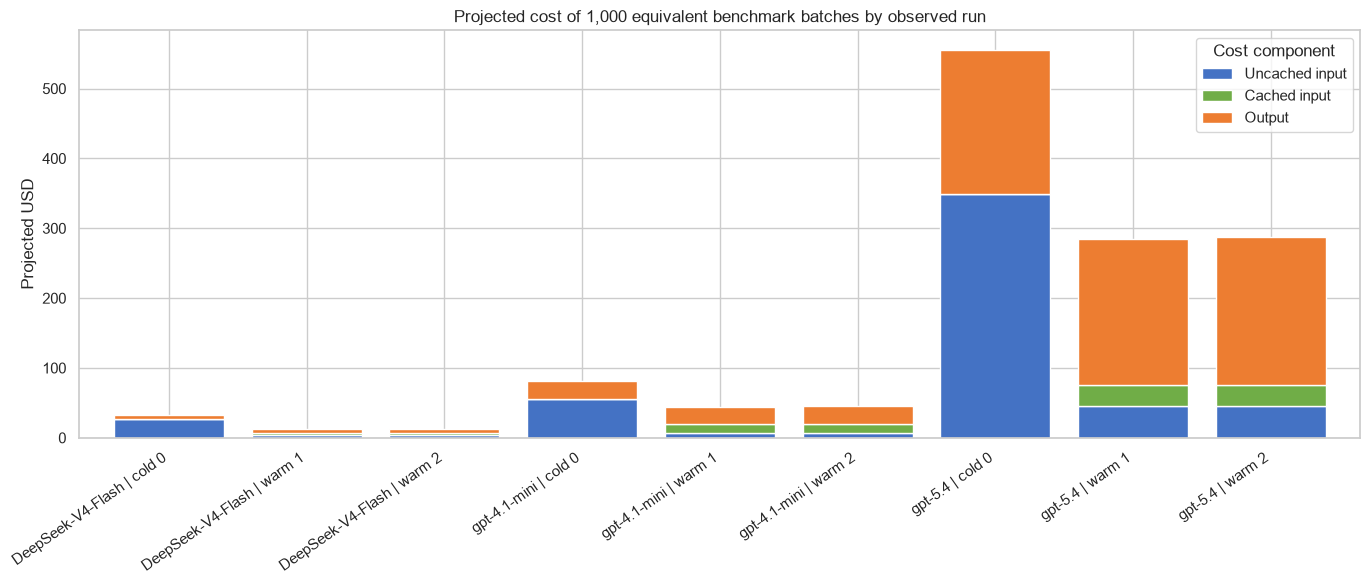

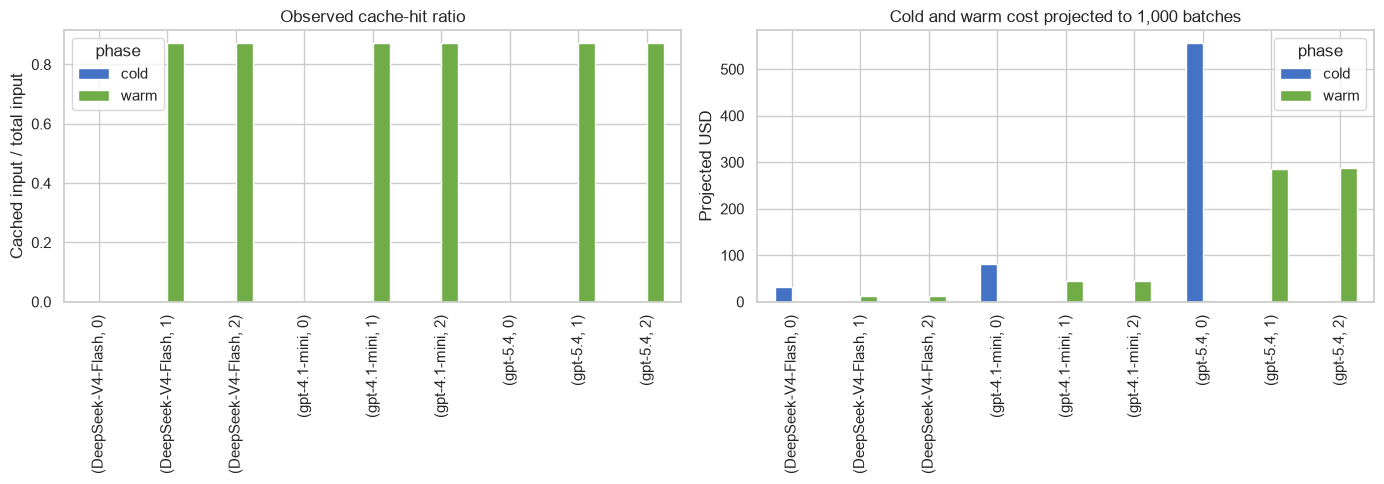

,cold_projected_1000_usd,warm_projected_1000_usd,projected_savings_1000_usd,savings_percent
model,,,,
DeepSeek-V4-Flash,32.61681,13.080978,19.535832,59.894981
gpt-4.1-mini,80.72960,44.748800,35.980800,44.569526
gpt-5.4,555.43500,286.479000,268.956000,48.422588


In [8]:
component_colors = ["#4472C4", "#70AD47", "#ED7D31"]

projected_components = run_df.set_index("run_label")[cost_components] * 1000

ax = projected_components.plot.bar(

    stacked=True, figsize=(14, 6), color=component_colors, width=0.8

)

ax.set_title("Projected cost of 1,000 equivalent benchmark batches by observed run")

ax.set_xlabel("")

ax.set_ylabel("Projected USD")

ax.legend(["Uncached input", "Cached input", "Output"], title="Cost component")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()

plt.show()



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cache_view = run_df.pivot_table(

    index=["model", "repetition"], columns="phase", values="cache_hit_ratio"

).fillna(0)

cache_view.plot.bar(ax=axes[0], color=["#4472C4", "#70AD47"])

axes[0].set_title("Observed cache-hit ratio")

axes[0].set_ylabel("Cached input / total input")

axes[0].set_xlabel("")

cost_view = run_df.pivot_table(

    index=["model", "repetition"], columns="phase", values="total_cost_usd"

) * 1000

cost_view.plot.bar(ax=axes[1], color=["#4472C4", "#70AD47"])

axes[1].set_title("Cold and warm cost projected to 1,000 batches")

axes[1].set_ylabel("Projected USD")

axes[1].set_xlabel("")

plt.tight_layout()

plt.show()



cold_cost = run_df[run_df.phase == "cold"].set_index("model")["total_cost_usd"]

warm_cost = run_df[run_df.phase == "warm"].groupby("model")["total_cost_usd"].mean()

savings_df = pd.DataFrame({"cold_cost_usd": cold_cost, "mean_warm_cost_usd": warm_cost})

savings_df["absolute_savings_usd"] = savings_df.cold_cost_usd - savings_df.mean_warm_cost_usd

savings_df["savings_percent"] = (

    savings_df.absolute_savings_usd / savings_df.cold_cost_usd * 100

)

display((savings_df * [1000, 1000, 1000, 1]).round(6).rename(columns={

    "cold_cost_usd": "cold_projected_1000_usd",

    "mean_warm_cost_usd": "warm_projected_1000_usd",

    "absolute_savings_usd": "projected_savings_1000_usd",

}))

,model,phase,mean,ci95_low,ci95_high
0,DeepSeek-V4-Flash,cold,32.616810,NaN,NaN
1,DeepSeek-V4-Flash,warm,13.080978,12.981018,13.180938
2,gpt-4.1-mini,cold,80.729600,NaN,NaN
3,gpt-4.1-mini,warm,44.748800,44.435200,45.062400
4,gpt-5.4,cold,555.435000,NaN,NaN
5,gpt-5.4,warm,286.479000,283.539000,289.419000


output_characters                        output_words  \
                                     mean median    std      var         mean   
model             phase                                                         
DeepSeek-V4-Flash cold             281.71  286.5  31.41   986.33        42.03   
                  warm             290.71  295.0  31.90  1017.55        42.53   
gpt-4.1-mini      cold             281.71  286.5  31.41   986.33        42.03   
                  warm             290.71  295.0  31.90  1017.55        42.53   
gpt-5.4           cold             287.71  292.5  31.41   986.33        42.03   
                  warm             296.71  301.0  31.90  1017.55        42.53   

                                            output_sentences               \
                        median   std    var             mean median   std   
model             phase                                                     
DeepSeek-V4-Flash cold    43.0  4.63  21.40              4.5    4.0  1.16   
                  warm    43.0  4.85  23.56              4.5    4.0  1.16   
gpt-4.1-mini      cold    43.0  4.63  21.40              4.5    4.0  1.16   
                  warm    43.0  4.85  23.56              4.5    4.0  1.16   
gpt-5.4           cold    43.0  4.63  21.40              4.5    4.0  1.16   
                  warm    43.0  4.85  23.56              4.5    4.0  1.16   

                              output_tokens                        
                          var          mean median    std     var  
model             phase                                            
DeepSeek-V4-Flash cold   1.34        119.75  120.0  10.11  102.21  
                  warm   1.34        122.75  122.0  10.13  102.70  
gpt-4.1-mini      cold   1.34        155.75  156.0  10.11  102.21  
                  warm   1.34        158.75  158.0  10.13  102.70  
gpt-5.4           cold   1.34        137.75  138.0  10.11  102.21  
                  warm   1.34        140.75  140.0  10.13  102.70

Empty responses: 0
Responses at completion limit: 0


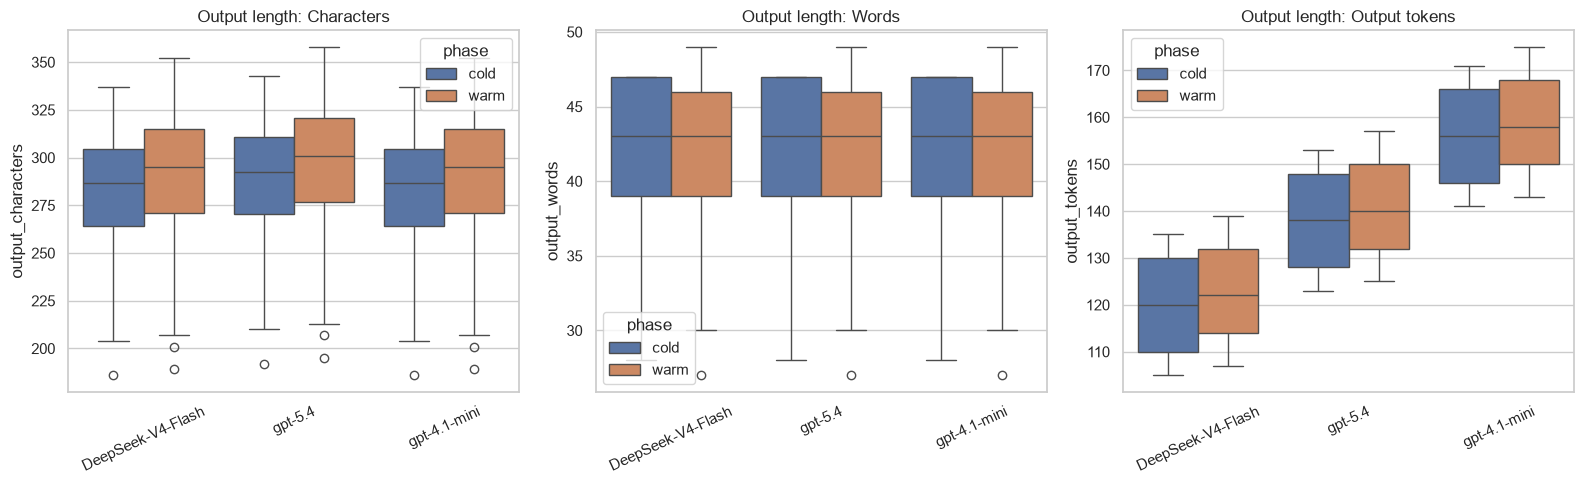

In [9]:
def mean_ci(values: pd.Series, scale: float = 1.0) -> pd.Series:

    clean = values.dropna().astype(float)

    mean = clean.mean() * scale

    if len(clean) < 2:

        return pd.Series({"mean": mean, "ci95_low": np.nan, "ci95_high": np.nan})

    margin = 1.96 * clean.std(ddof=1) / math.sqrt(len(clean)) * scale

    return pd.Series({"mean": mean, "ci95_low": mean - margin, "ci95_high": mean + margin})



projection_df = (

    run_df.groupby(["model", "phase"])["total_cost_usd"]

    .apply(lambda values: mean_ci(values, scale=1000))

    .unstack()

    .reset_index()

)

display(projection_df.round(6))



length_columns = [

    "output_characters", "output_words", "output_sentences", "output_tokens"

]

length_summary = results_df.groupby(["model", "phase"])[length_columns].agg(

    ["mean", "median", "std", "var"]

)

display(length_summary.round(2))

print("Empty responses:", int((results_df.output_characters == 0).sum()))

print("Responses at completion limit:", int((results_df.output_tokens >= MAX_COMPLETION_TOKENS).sum()))



fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for axis, metric, title in zip(

    axes,

    ["output_characters", "output_words", "output_tokens"],

    ["Characters", "Words", "Output tokens"],

):

    sns.boxplot(data=results_df, x="model", y=metric, hue="phase", ax=axis)

    axis.set_title(f"Output length: {title}")

    axis.set_xlabel("")

    axis.tick_params(axis="x", rotation=25)

plt.tight_layout()

plt.show()

## 17. Generate Text Embeddings for Model Outputs



Live embeddings are batched, retried for transient failures, and cached locally by deployment plus text hash. Embedding token usage and optional cost are tracked separately from generation. Synthetic validation uses deterministic TF-IDF vectors, so it does not claim equivalence to a production embedding model.



## 18. Calculate Semantic Similarity and k-Nearest Neighbors



Cosine similarity and neighbors are calculated **only within the same prompt**. Each output is also compared with its reference text where the reference is nonempty. Cross-model scorecards compare the same phase and repetition before averaging by prompt, which prevents unrelated prompts or mixed run conditions from distorting agreement statistics.



## 19. Visualize Semantic Similarity by Model and Run Type



PCA provides a deterministic 2D overview; lines connect same-prompt nearest neighbors. The displayed 2D distance is an approximation and must not replace cosine similarity measured in the original vector space.



## 20. Calculate Aggregate Similarity Mean and Variance



Pair types are reported separately: within-model repeats, cold-to-warm consistency, cross-model agreement, and reference similarity. The three cross-model pairs are shown independently. Cosine similarity is the primary semantic-agreement measure. The per-run Pearson line chart is a secondary measure of centered embedding-coordinate alignment; neither measure establishes correctness or safety. Statistics first aggregate at prompt level so prompts with more repetitions do not receive extra weight.

In [10]:
EMBEDDING_CACHE_PATH = OUTPUT_DIR / "embedding_cache.json"

EMBEDDING_BATCH_SIZE = 64

EMBEDDING_PRICE_PER_1M_USD = (

    float(os.environ["EMBEDDING_PRICE_PER_1M_USD"])

    if os.getenv("EMBEDDING_PRICE_PER_1M_USD") else None

)



def text_key(text: str) -> str:

    material = f"{EMBEDDING_DEPLOYMENT}\0{text}".encode("utf-8")

    return hashlib.sha256(material).hexdigest()



def live_embeddings(texts: list[str]) -> tuple[np.ndarray, dict]:

    if not RUN_LIVE or openai_client is None:

        raise RuntimeError("Live embeddings require RUN_LIVE=True and a configured client.")

    cache = {}

    if EMBEDDING_CACHE_PATH.exists():

        cache = json.loads(EMBEDDING_CACHE_PATH.read_text(encoding="utf-8"))

    missing = [(text_key(text), text) for text in dict.fromkeys(texts) if text_key(text) not in cache]

    embedding_tokens = 0

    for offset in range(0, len(missing), EMBEDDING_BATCH_SIZE):

        batch = missing[offset:offset + EMBEDDING_BATCH_SIZE]

        for attempt in range(5):

            try:

                response = openai_client.embeddings.create(

                    model=EMBEDDING_DEPLOYMENT, input=[text for _, text in batch]

                )

                for (key, _), item in zip(batch, response.data):

                    cache[key] = item.embedding

                usage = getattr(response, "usage", None)

                embedding_tokens += int(getattr(usage, "total_tokens", 0) or 0)

                break

            except Exception:

                if attempt == 4:

                    raise

                time.sleep(2 ** attempt)

    EMBEDDING_CACHE_PATH.write_text(json.dumps(cache), encoding="utf-8")

    vectors = np.asarray([cache[text_key(text)] for text in texts], dtype=float)

    embedding_cost = (

        embedding_tokens * EMBEDDING_PRICE_PER_1M_USD / 1_000_000

        if EMBEDDING_PRICE_PER_1M_USD is not None else np.nan

    )

    return vectors, {

        "embedding_tokens": embedding_tokens,

        "embedding_cost_usd": embedding_cost,

        "embedding_method": EMBEDDING_DEPLOYMENT,

    }



output_texts = results_df["output_text"].fillna("").tolist()

reference_by_prompt = evaluation_df.set_index("prompt_id")["ground_truth"].fillna("").to_dict()

reference_texts = [reference_by_prompt[prompt_id] for prompt_id in results_df.prompt_id]

combined_texts = output_texts + reference_texts



if RUN_LIVE:

    combined_vectors, embedding_usage = live_embeddings(combined_texts)

else:

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=4096)

    combined_vectors = vectorizer.fit_transform(combined_texts).toarray()

    embedding_usage = {

        "embedding_tokens": 0, "embedding_cost_usd": 0.0,

        "embedding_method": "local deterministic TF-IDF validation",

    }



output_vectors = combined_vectors[:len(results_df)]

reference_vectors = combined_vectors[len(results_df):]

norms = np.linalg.norm(output_vectors, axis=1, keepdims=True)

output_vectors = output_vectors / np.where(norms == 0, 1, norms)

reference_norms = np.linalg.norm(reference_vectors, axis=1, keepdims=True)

reference_vectors = reference_vectors / np.where(reference_norms == 0, 1, reference_norms)

results_df["reference_similarity"] = np.sum(output_vectors * reference_vectors, axis=1)

display(pd.DataFrame([embedding_usage]))

,embedding_tokens,embedding_cost_usd,embedding_method
0,0,0.0,local deterministic TF-IDF validation


In [ ]:
pair_records = []
knn_scores = np.full(len(results_df), np.nan)
nearest_indices = np.full(len(results_df), -1, dtype=int)

for prompt_id, group in results_df.groupby("prompt_id", sort=False):
    indices = group.index.to_numpy()
    vectors = output_vectors[indices]
    similarities = cosine_similarity(vectors)
    neighbor_count = min(2, len(indices) - 1)
    if neighbor_count > 0:
        ordered = np.argsort(-similarities, axis=1)
        for local_index, row_index in enumerate(indices):
            neighbors = ordered[local_index, 1:neighbor_count + 1]
            knn_scores[row_index] = similarities[local_index, neighbors].mean()
            nearest_indices[row_index] = indices[neighbors[0]]
    for left in range(len(indices)):
        for right in range(left + 1, len(indices)):
            left_row, right_row = group.iloc[left], group.iloc[right]
            if left_row.model == right_row.model and left_row.phase == right_row.phase:
                pair_type = "within-model repeat"
            elif left_row.model == right_row.model:
                pair_type = "cold-to-warm consistency"
            else:
                pair_type = "cross-model agreement"
            pair_records.append({
                "prompt_id": prompt_id,
                "left_model": left_row.model,
                "right_model": right_row.model,
                "left_phase": left_row.phase,
                "right_phase": right_row.phase,
                "left_repetition": left_row.repetition,
                "right_repetition": right_row.repetition,
                "left_row_index": indices[left],
                "right_row_index": indices[right],
                "pair_type": pair_type,
                "cosine_similarity": similarities[left, right],
            })

results_df["mean_knn_similarity"] = knn_scores
results_df["nearest_row_index"] = nearest_indices
pair_df = pd.DataFrame(pair_records)
reference_pairs = results_df[["prompt_id", "model", "phase", "reference_similarity"]].copy()
reference_pairs["pair_type"] = "reference similarity"

prompt_pair_means = pair_df.groupby(["prompt_id", "pair_type"], as_index=False).agg(
    similarity=("cosine_similarity", "mean")
)
prompt_reference_means = reference_pairs.groupby(["prompt_id", "pair_type"], as_index=False).agg(
    similarity=("reference_similarity", "mean")
)
prompt_balanced = pd.concat([prompt_pair_means, prompt_reference_means], ignore_index=True)


def similarity_statistics(group: pd.DataFrame) -> pd.Series:
    values = group["similarity"].dropna()
    interval = mean_ci(values)
    return pd.Series({
        "prompts": values.size,
        "mean": values.mean(),
        "variance": values.var(ddof=1),
        "std_dev": values.std(ddof=1),
        "ci95_low": interval.ci95_low,
        "ci95_high": interval.ci95_high,
    })


similarity_summary = prompt_balanced.groupby("pair_type").apply(
    similarity_statistics, include_groups=False
).reset_index()
model_similarity_summary = results_df.groupby(["model", "phase"]).agg(
    mean_knn_similarity=("mean_knn_similarity", "mean"),
    variance_knn_similarity=("mean_knn_similarity", "var"),
    std_knn_similarity=("mean_knn_similarity", "std"),
    mean_reference_similarity=("reference_similarity", "mean"),
).reset_index()

comparison_model_order = ["DeepSeek-V4-Flash", "gpt-4.1-mini", "gpt-5.4"]
assert set(comparison_model_order) == set(MODELS)
model_rank = {model: position for position, model in enumerate(comparison_model_order)}
matched_cross_model_pairs = pair_df[
    (pair_df["pair_type"] == "cross-model agreement")
    & (pair_df["left_phase"] == pair_df["right_phase"])
    & (pair_df["left_repetition"] == pair_df["right_repetition"])
].copy()
matched_cross_model_pairs["model_pair"] = matched_cross_model_pairs.apply(
    lambda row: " vs ".join(sorted(
        [row.left_model, row.right_model], key=model_rank.get
    )),
    axis=1,
)
model_pair_prompt_means = matched_cross_model_pairs.groupby(
    ["prompt_id", "model_pair"], as_index=False
).agg(similarity=("cosine_similarity", "mean"))
model_pair_similarity_summary = model_pair_prompt_means.groupby("model_pair").apply(
    similarity_statistics, include_groups=False
).reset_index()

def embedding_correlation(row: pd.Series) -> float:
    left_vector = output_vectors[int(row.left_row_index)]
    right_vector = output_vectors[int(row.right_row_index)]
    if np.std(left_vector) == 0 or np.std(right_vector) == 0:
        return np.nan
    return float(np.corrcoef(left_vector, right_vector)[0, 1])

matched_cross_model_pairs["embedding_correlation"] = matched_cross_model_pairs.apply(
    embedding_correlation, axis=1
)
matched_cross_model_pairs["run_label"] = matched_cross_model_pairs.apply(
    lambda row: f"{row.left_phase.title()} {int(row.left_repetition)}", axis=1
)
matched_cross_model_pairs["run_order"] = matched_cross_model_pairs.apply(
    lambda row: 0 if row.left_phase == "cold" else int(row.left_repetition), axis=1
)
correlation_run_values = matched_cross_model_pairs.rename(
    columns={"embedding_correlation": "similarity"}
)
model_pair_correlation_summary = correlation_run_values.groupby(
    ["model_pair", "run_label", "run_order"]
).apply(similarity_statistics, include_groups=False).reset_index()
model_pair_correlation_summary = model_pair_correlation_summary.sort_values(
    ["model_pair", "run_order"]
)
expected_model_pairs = len(MODELS) * (len(MODELS) - 1) // 2
assert len(model_pair_similarity_summary) == expected_model_pairs

print("Overall consistency and agreement")
display(similarity_summary.round(5))
print("Cross-model response similarity (matched prompt, phase, and repetition)")
display(model_pair_similarity_summary.round(5))
print("Per-run Pearson correlation across embedding dimensions")
display(model_pair_correlation_summary.round(5))
display(model_similarity_summary.round(5))

,pair_type,prompts,mean,variance,std_dev,ci95_low,ci95_high
0,cold-to-warm consistency,100.0,0.87516,0.00141,0.03759,0.86779,0.88252
1,cross-model agreement,100.0,0.88967,0.00110,0.03314,0.88318,0.89617
2,reference similarity,100.0,0.18664,0.02492,0.15785,0.15570,0.21758
3,within-model repeat,100.0,0.87125,0.00150,0.03869,0.86366,0.87883


,model,phase,mean_knn_similarity,variance_knn_similarity,std_knn_similarity,mean_reference_similarity
0,DeepSeek-V4-Flash,cold,0.97422,0.00006,0.00794,0.18766
1,DeepSeek-V4-Flash,warm,0.97455,0.00006,0.00772,0.18646
2,gpt-4.1-mini,cold,0.97410,0.00006,0.00797,0.18764
3,gpt-4.1-mini,warm,0.97444,0.00006,0.00775,0.18644
4,gpt-5.4,cold,0.97228,0.00007,0.00849,0.18701
5,gpt-5.4,warm,0.97264,0.00007,0.00825,0.18583


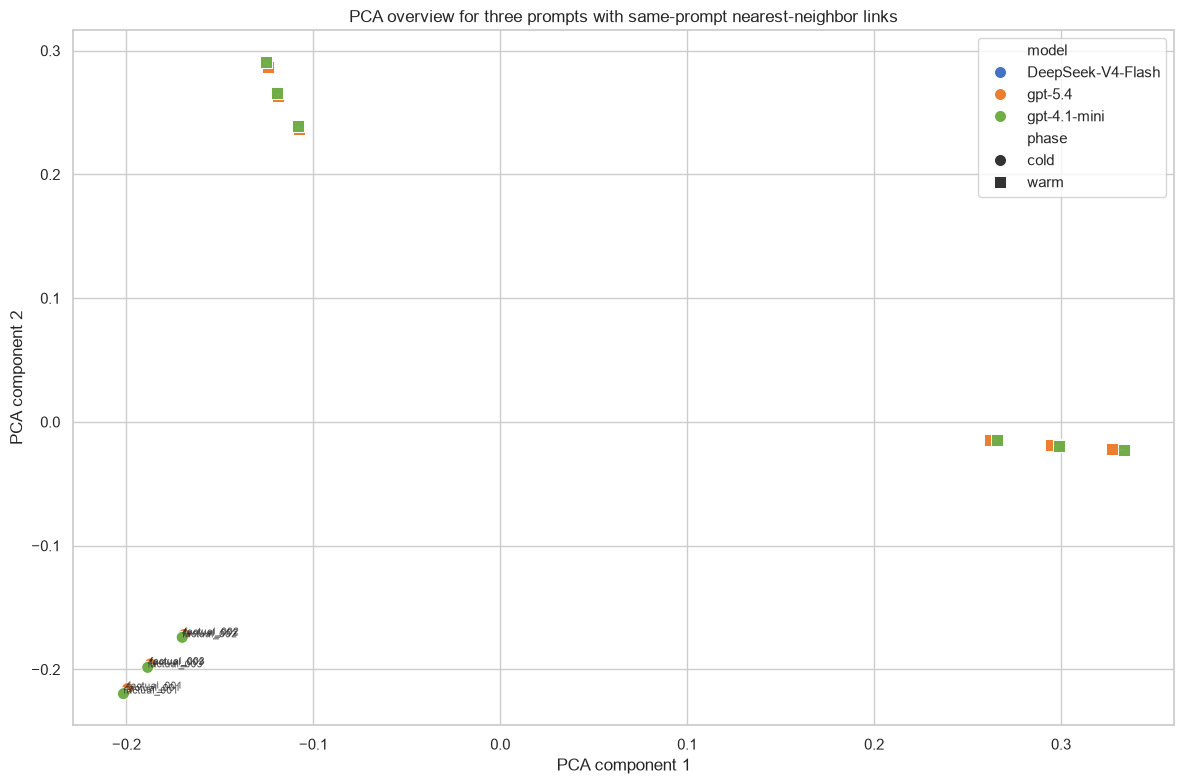

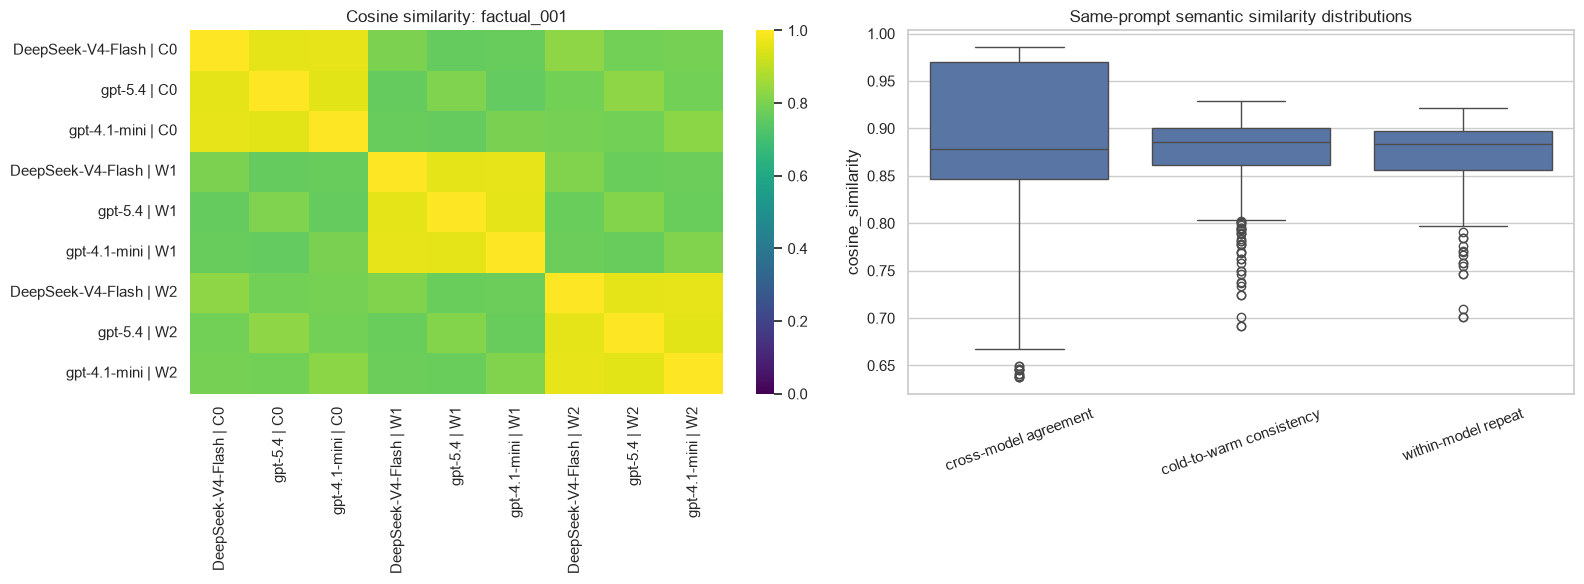

In [ ]:
pca_coordinates = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(output_vectors)

results_df[["pca_1", "pca_2"]] = pca_coordinates

selected_prompts = results_df["prompt_id"].drop_duplicates().head(3).tolist()

plot_df = results_df[results_df.prompt_id.isin(selected_prompts)].copy()



fig, axis = plt.subplots(figsize=(12, 8))

markers = {"cold": "o", "warm": "s"}

palette = dict(zip(MODELS, ["#4472C4", "#ED7D31", "#70AD47"]))

sns.scatterplot(

    data=plot_df, x="pca_1", y="pca_2", hue="model", style="phase",

    markers=markers, palette=palette, s=75, ax=axis,

)

for row_index, row in plot_df.iterrows():

    neighbor_index = int(row.nearest_row_index)

    if neighbor_index in plot_df.index:

        neighbor = results_df.loc[neighbor_index]

        axis.plot(

            [row.pca_1, neighbor.pca_1], [row.pca_2, neighbor.pca_2],

            color="#A5A5A5", alpha=0.2, linewidth=0.8,

        )

    if row.repetition == 0:

        axis.annotate(row.prompt_id, (row.pca_1, row.pca_2), fontsize=7, alpha=0.8)

axis.set_title("PCA overview for three prompts with same-prompt nearest-neighbor links")

axis.set_xlabel("PCA component 1")

axis.set_ylabel("PCA component 2")

plt.tight_layout()

plt.show()



sample_prompt = selected_prompts[0]

sample_indices = results_df.index[results_df.prompt_id == sample_prompt].to_numpy()

sample_labels = results_df.loc[sample_indices].apply(

    lambda row: f"{row.model} | {row.phase[0].upper()}{row.repetition}", axis=1

)

sample_similarity = cosine_similarity(output_vectors[sample_indices])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(

    sample_similarity, xticklabels=sample_labels, yticklabels=sample_labels,

    cmap="viridis", vmin=0, vmax=1, ax=axes[0],

)

axes[0].set_title(f"Cosine similarity: {sample_prompt}")

sns.boxplot(data=pair_df, x="pair_type", y="cosine_similarity", ax=axes[1])

axes[1].set_title("Same-prompt semantic similarity distributions")

axes[1].set_xlabel("")

axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()

plt.show()



pair_chart_df = model_pair_similarity_summary.copy()

pair_chart_df["label"] = pair_chart_df["model_pair"].str.replace(" vs ", "\nvs\n", regex=False)

pair_error = np.vstack([

    pair_chart_df["mean"] - pair_chart_df["ci95_low"],

    pair_chart_df["ci95_high"] - pair_chart_df["mean"],

])

fig, axis = plt.subplots(figsize=(12, 6))

bars = axis.bar(

    pair_chart_df["label"], pair_chart_df["mean"], yerr=pair_error,

    capsize=5, color=["#4472C4", "#ED7D31", "#70AD47"],

)

axis.bar_label(bars, fmt="%.3f", padding=4)

axis.set_ylim(0, 1.05)

axis.set_title("Cross-model response cosine similarity")

axis.set_xlabel("Matched model outputs")

axis.set_ylabel("Prompt-balanced mean cosine similarity (95% CI)")

plt.tight_layout()

model_pair_chart_path = OUTPUT_DIR / "model_pair_similarity.png"

plt.savefig(model_pair_chart_path, dpi=160, bbox_inches="tight")

plt.show()



fig, axis = plt.subplots(figsize=(12, 6))

correlation_colors = ["#4472C4", "#ED7D31", "#70AD47"]

for color, (model_pair, group) in zip(

    correlation_colors, model_pair_correlation_summary.groupby("model_pair", sort=False)

):

    group = group.sort_values("run_order")

    axis.errorbar(

        group["run_order"], group["mean"],

        yerr=np.vstack([group["mean"] - group["ci95_low"],

                        group["ci95_high"] - group["mean"]]),

        marker="o", linewidth=2, capsize=4, color=color, label=model_pair,

    )

run_ticks = model_pair_correlation_summary[["run_order", "run_label"]].drop_duplicates().sort_values("run_order")

axis.set_xticks(run_ticks["run_order"], run_ticks["run_label"])

axis.set_ylim(-1.05, 1.05)

axis.axhline(0, color="#666666", linewidth=1, alpha=0.6)

axis.set_title("Per-run Pearson correlation of matched output embeddings")

axis.set_xlabel("Run condition")

axis.set_ylabel("Mean Pearson correlation across embedding dimensions (95% CI)")

axis.legend(title="Model pair", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

model_pair_correlation_chart_path = OUTPUT_DIR / "model_pair_correlation_by_run.png"

plt.savefig(model_pair_correlation_chart_path, dpi=160, bbox_inches="tight")

plt.show()

## 21. Compare Cost, Cache Efficiency, Latency, Length, and Quality



The decision table combines commercial and operational measures with semantic consistency. Foundry evaluator quality is joined only when `foundry_quality_scores.csv` exists with `model`, `phase`, and `quality_score` columns. Synthetic mode leaves evaluator quality missing by design: similarity measures consistency, not correctness or safety.



## 22. Export Reproducible Results and Decision Artifacts



Detailed observations, pairwise similarities, aggregate statistics, vectors, charts, and an experiment manifest are exported together. The manifest records dataset and pricing hashes, package versions, run guards, embedding method, and interpretation limits so another reviewer can reproduce the analysis.

,model,phase,projected_1000_item_cost_usd,mean_cache_hit_ratio,mean_latency_ms,mean_output_tokens,mean_knn_similarity,mean_reference_similarity,evaluator_quality,quality_source
0,DeepSeek-V4-Flash,cold,0.32617,0.00000,434.730,119.75,0.97422,0.18766,NaN,not evaluated in synthetic mode
1,DeepSeek-V4-Flash,warm,0.13081,0.87173,435.000,122.75,0.97455,0.18646,NaN,not evaluated in synthetic mode
2,gpt-4.1-mini,cold,0.80730,0.00000,625.030,155.75,0.97410,0.18764,NaN,not evaluated in synthetic mode
3,gpt-4.1-mini,warm,0.44749,0.87173,624.990,158.75,0.97444,0.18644,NaN,not evaluated in synthetic mode
4,gpt-5.4,cold,5.55435,0.00000,529.880,137.75,0.97228,0.18701,NaN,not evaluated in synthetic mode
5,gpt-5.4,warm,2.86479,0.87173,529.995,140.75,0.97264,0.18583,NaN,not evaluated in synthetic mode


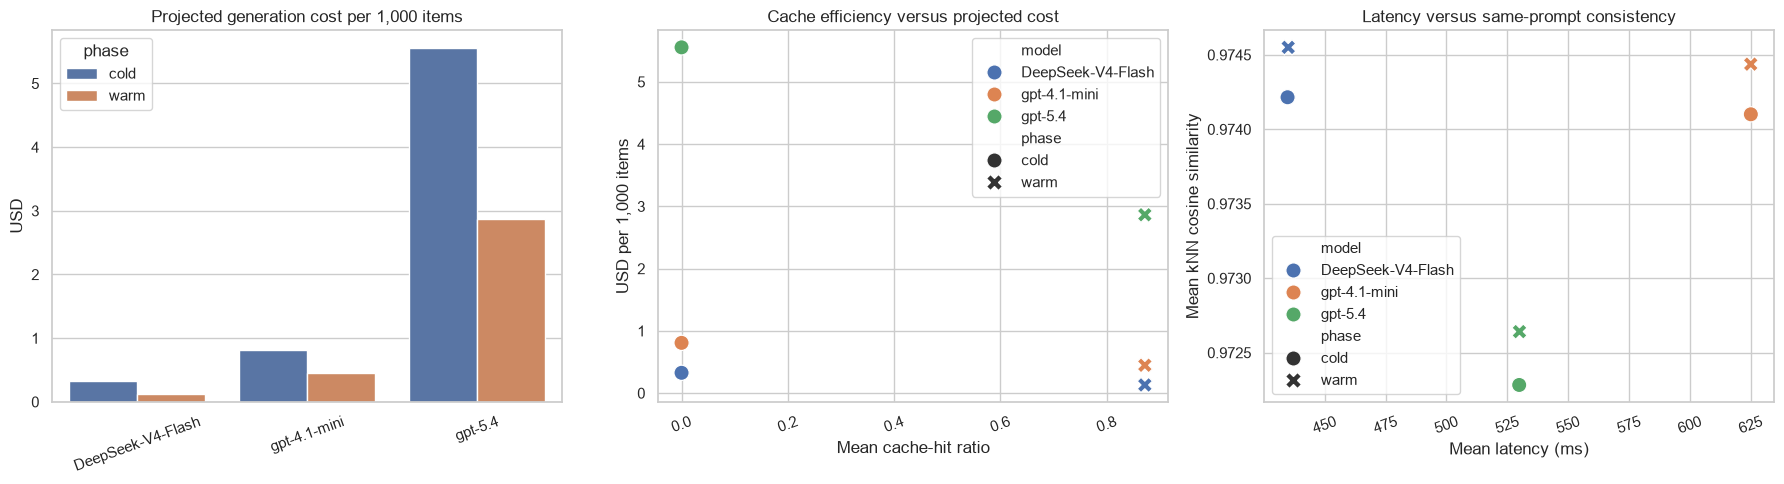

In [13]:
quality_path = OUTPUT_DIR / "foundry_quality_scores.csv"

if quality_path.exists():

    quality_df = pd.read_csv(quality_path)

    required_quality_columns = {"model", "phase", "quality_score"}

    if not required_quality_columns.issubset(quality_df.columns):

        raise ValueError(f"{quality_path.name} must contain {sorted(required_quality_columns)}")

    quality_summary = quality_df.groupby(["model", "phase"], as_index=False).agg(

        evaluator_quality=("quality_score", "mean")

    )

    quality_source = "Foundry evaluator export"

else:

    quality_summary = pd.DataFrame({

        "model": MODELS,

        "phase": ["warm"] * len(MODELS),

        "evaluator_quality": [np.nan] * len(MODELS),

    })

    quality_source = "not evaluated in synthetic mode"



operational_summary = results_df.groupby(["model", "phase"], as_index=False).agg(

    mean_item_cost_usd=("total_cost_usd", "mean"),

    mean_cache_hit_ratio=("cache_hit_ratio", "mean"),

    mean_latency_ms=("latency_ms", "mean"),

    mean_output_tokens=("output_tokens", "mean"),

    mean_output_words=("output_words", "mean"),

    mean_knn_similarity=("mean_knn_similarity", "mean"),

    mean_reference_similarity=("reference_similarity", "mean"),

)

decision_df = (

    operational_summary

    .merge(model_similarity_summary, on=["model", "phase"], suffixes=("", "_summary"))

    .merge(quality_summary, on=["model", "phase"], how="left")

)

decision_df["projected_1000_item_cost_usd"] = decision_df.mean_item_cost_usd * 1000

decision_df["quality_source"] = quality_source

decision_columns = [

    "model", "phase", "projected_1000_item_cost_usd", "mean_cache_hit_ratio",

    "mean_latency_ms", "mean_output_tokens", "mean_knn_similarity",

    "mean_reference_similarity", "evaluator_quality", "quality_source",

]

display(decision_df[decision_columns].round(5))



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(

    data=decision_df, x="model", y="projected_1000_item_cost_usd", hue="phase", ax=axes[0]

)

axes[0].set_title("Projected generation cost per 1,000 items")

axes[0].set_xlabel("")

axes[0].set_ylabel("USD")

sns.scatterplot(

    data=decision_df, x="mean_cache_hit_ratio", y="projected_1000_item_cost_usd",

    hue="model", style="phase", s=120, ax=axes[1],

)

axes[1].set_title("Cache efficiency versus projected cost")

axes[1].set_xlabel("Mean cache-hit ratio")

axes[1].set_ylabel("USD per 1,000 items")

sns.scatterplot(

    data=decision_df, x="mean_latency_ms", y="mean_knn_similarity",

    hue="model", style="phase", s=120, ax=axes[2],

)

axes[2].set_title("Latency versus same-prompt consistency")

axes[2].set_xlabel("Mean latency (ms)")

axes[2].set_ylabel("Mean kNN cosine similarity")

for axis in axes:

    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()

decision_chart_path = OUTPUT_DIR / "decision_dashboard.png"

plt.savefig(decision_chart_path, dpi=160, bbox_inches="tight")

plt.show()

In [ ]:
artifact_paths = {

    "detailed_results": OUTPUT_DIR / "benchmark_detailed_results.csv",

    "run_summary": OUTPUT_DIR / "benchmark_run_summary.csv",

    "model_summary": OUTPUT_DIR / "benchmark_model_summary.csv",

    "decision_summary": OUTPUT_DIR / "decision_summary.csv",

    "similarity_pairs": OUTPUT_DIR / "similarity_pairs.csv",

    "similarity_summary": OUTPUT_DIR / "similarity_summary.csv",

    "matched_cross_model_pairs": OUTPUT_DIR / "matched_cross_model_pairs.csv",

    "model_pair_similarity_summary": OUTPUT_DIR / "model_pair_similarity_summary.csv",

    "model_pair_correlation_summary": OUTPUT_DIR / "model_pair_correlation_summary.csv",

    "projection_summary": OUTPUT_DIR / "projection_summary.csv",

    "output_vectors": OUTPUT_DIR / "output_vectors.npy",

    "decision_chart": decision_chart_path,

    "model_pair_similarity_chart": model_pair_chart_path,

    "model_pair_correlation_chart": model_pair_correlation_chart_path,

}

results_df.to_csv(artifact_paths["detailed_results"], index=False)

run_df.to_csv(artifact_paths["run_summary"], index=False)

model_df.to_csv(artifact_paths["model_summary"], index=False)

decision_df[decision_columns].to_csv(artifact_paths["decision_summary"], index=False)

pair_df.to_csv(artifact_paths["similarity_pairs"], index=False)

similarity_summary.to_csv(artifact_paths["similarity_summary"], index=False)

matched_cross_model_pairs.to_csv(artifact_paths["matched_cross_model_pairs"], index=False)

model_pair_similarity_summary.to_csv(artifact_paths["model_pair_similarity_summary"], index=False)

model_pair_correlation_summary.to_csv(artifact_paths["model_pair_correlation_summary"], index=False)

projection_df.to_csv(artifact_paths["projection_summary"], index=False)

np.save(artifact_paths["output_vectors"], output_vectors)



def sha256_file(path: Path) -> str:

    return hashlib.sha256(path.read_bytes()).hexdigest()



manifest = {

    "created_utc": datetime.now(timezone.utc).isoformat(),

    "execution_mode": "live" if RUN_LIVE else "synthetic",

    "live_model_calls_enabled": RUN_LIVE,

    "foundry_assets_enabled": CREATE_FOUNDRY_ASSETS,

    "foundry_evaluation_runs_enabled": START_FOUNDRY_EVALUATION_RUNS,

    "dataset": {

        "path": DATASET_PATH.name,

        "sha256": sha256_file(DATASET_PATH),

        "rows": len(evaluation_df),

    },

    "pricing": {

        "path": "model_pricing.json",

        "sha256": sha256_file(NOTEBOOK_DIR / "model_pricing.json"),

        "retrieved_date": pricing_metadata["retrieved_date"],

        "rates": pricing_metadata["rates"],

    },

    "experiment": {

        "models": MODELS,

        "warm_repetitions": WARM_REPETITIONS,

        "cache_experiment_enabled": ENABLE_CACHE_EXPERIMENT,

        "max_completion_tokens": MAX_COMPLETION_TOKENS,

        "random_seed": RANDOM_SEED,

        "observations": len(results_df),

    },

    "embeddings": embedding_usage,

    "quality_source": quality_source,

    "packages": versions,

    "limitations": [

        "Synthetic token, cache, latency, response, and similarity values are illustrative.",

        "Cosine similarity measures semantic consistency, not factual correctness or safety.",

        "Pearson correlation measures centered embedding-coordinate alignment and is a secondary diagnostic, not a quality score.",

        "PCA distances are a two-dimensional visualization approximation.",

        "The 1,000-unit projections are linear estimates from observed means.",

        "Embedding charges are separate from generation charges.",

    ],

    "artifacts": {name: str(path.relative_to(NOTEBOOK_DIR)) for name, path in artifact_paths.items()},

    "foundry_assets": foundry_asset_manifest,

}

manifest_path = OUTPUT_DIR / "experiment_manifest.json"

manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")



export_manifest = pd.DataFrame([

    {"artifact": name, "path": str(path), "exists": path.exists(), "bytes": path.stat().st_size}

    for name, path in {**artifact_paths, "experiment_manifest": manifest_path}.items()

])

display(export_manifest)

print("Reproducible artifact manifest:", manifest_path)

,artifact,path,exists,bytes
0,detailed_results,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,727398
1,run_summary,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,1563
2,model_summary,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,469
3,decision_summary,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,948
4,similarity_pairs,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,321258
5,similarity_summary,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,572
6,projection_summary,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,290
7,output_vectors,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,25171328
8,decision_chart,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,141672
9,experiment_manifest,C:\Users\rodonnell\code\copilot-worktrees\Foun...,True,3397


Reproducible artifact manifest: C:\Users\rodonnell\code\copilot-worktrees\Foundry-DeepSeek-Accelerator\rodonnell-microsoft-curly-carnival\kits\cost-assessment-kit\analysis_results\experiment_manifest.json
